In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
%matplotlib inline

# Caricamento e preparazione indice
df = pd.read_csv('../data/raw/nvidia/NVDA.csv') # Assicurati che il percorso sia corretto
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Trasformazioni iniziali
ts = df['Adj Close']
ts_log = np.log(ts)

# Split Train/Test (30 giorni)
steps_test = 30
train_endog = ts_log[:-steps_test]
test_endog = ts_log[-steps_test:]

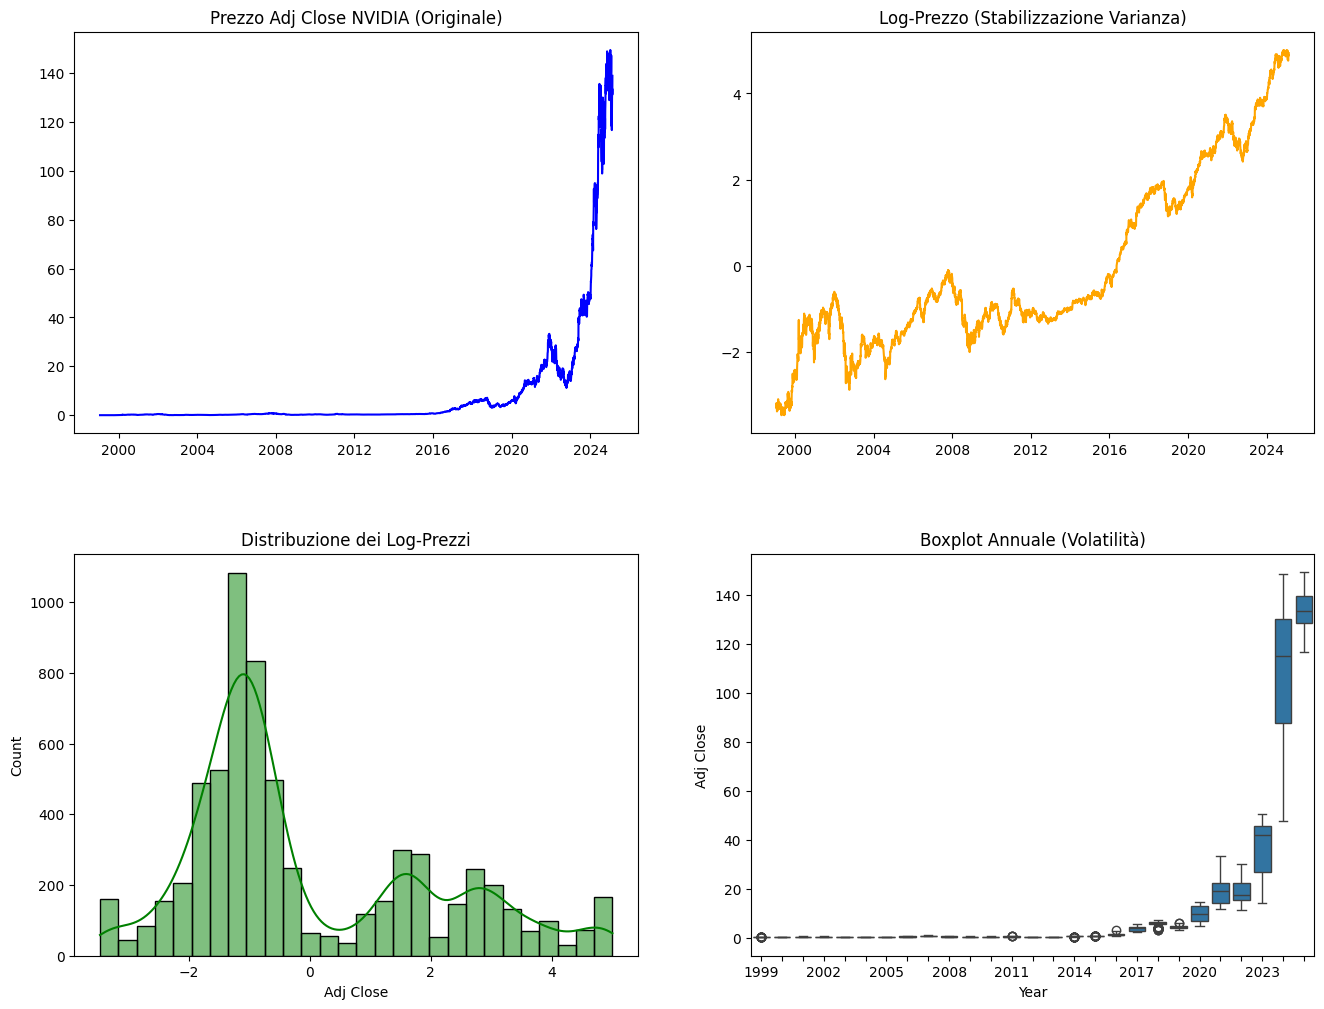

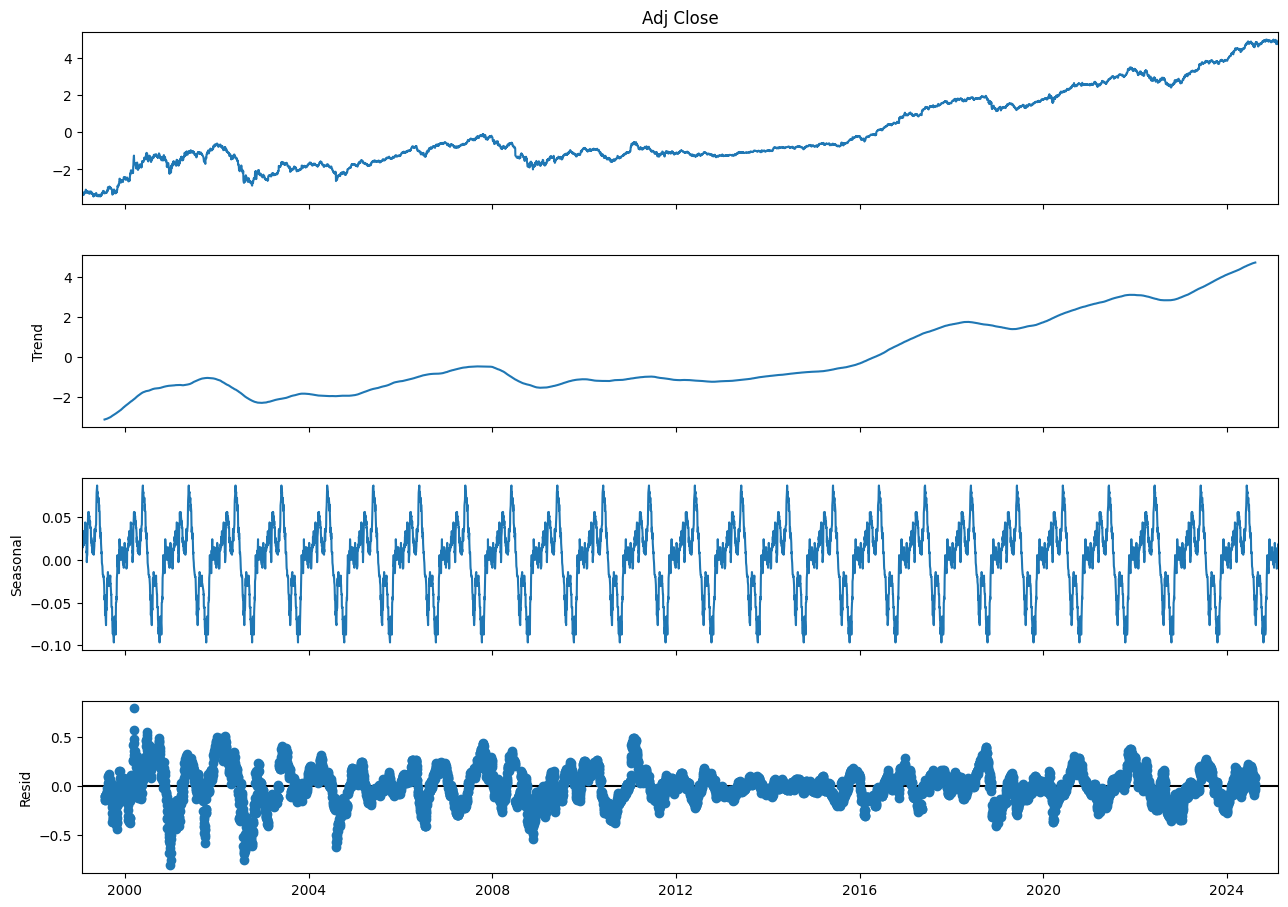

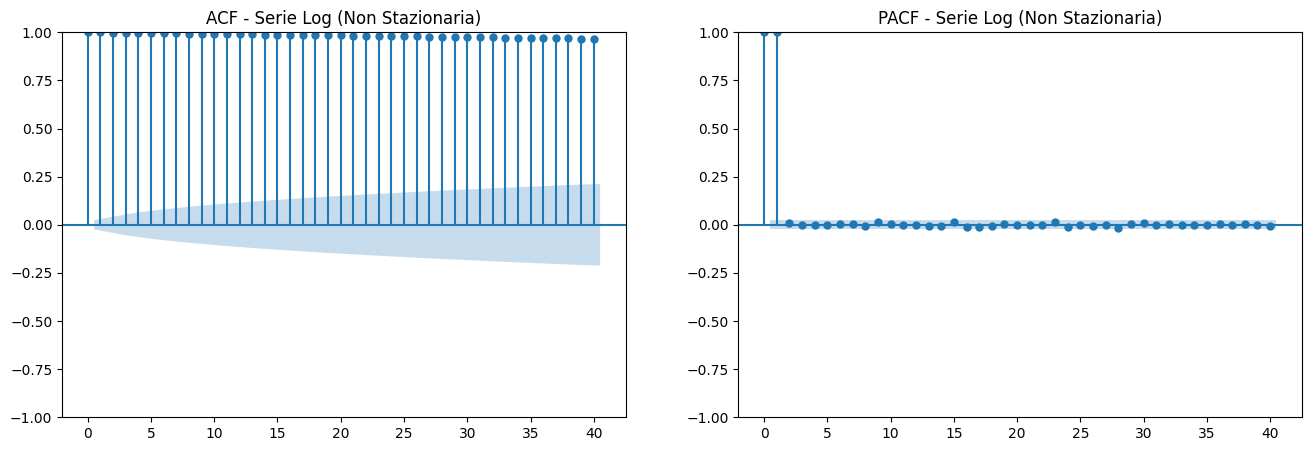

In [4]:
# Grafico Analisi Iniziale (Trend, Log, Distribuzione, Boxplot)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3)

axes[0, 0].plot(ts, color='blue')
axes[0, 0].set_title('Prezzo Adj Close NVIDIA (Originale)')
axes[0, 1].plot(ts_log, color='orange')
axes[0, 1].set_title('Log-Prezzo (Stabilizzazione Varianza)')
sns.histplot(ts_log, kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Distribuzione dei Log-Prezzi')

df_box = df.copy()
df_box['Year'] = df_box.index.year
sns.boxplot(data=df_box, x='Year', y='Adj Close', ax=axes[1, 1])
axes[1, 1].set_title('Boxplot Annuale (Volatilità)')
for i, label in enumerate(axes[1, 1].get_xticklabels()):
    if i % 3 != 0: label.set_visible(False)
plt.show()

# Decomposizione Stagionale
decomposition = seasonal_decompose(ts_log, model='additive', period=252)
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

# ACF/PACF sulla serie NON stazionaria (mostra il trend)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(ts_log, ax=ax1, lags=40, title='ACF - Serie Log (Non Stazionaria)')
plot_pacf(ts_log, ax=ax2, lags=40, title='PACF - Serie Log (Non Stazionaria)')
plt.show()

In [17]:
# Calcolo del test sulla serie dei Log-Prezzi (NON differenziata)
result_non_diff = adfuller(ts_log.dropna())

print("TABELLA ADF (NVIDIA Log-Prezzi - NON stazionaria):")
print(f"{'-'*40}")
print(f"ADF Statistic: {result_non_diff[0]:.4f}")
print(f"p-value: {result_non_diff[1]:.4f}")
print(f"Critical Value (1%): {result_non_diff[4]['1%']:.3f}")
print(f"Critical Value (5%): {result_non_diff[4]['5%']:.3f}")
print(f"Critical Value (10%): {result_non_diff[4]['10%']:.3f}")
print(f"{'-'*40}")

TABELLA ADF (NVIDIA Log-Prezzi - NON stazionaria):
----------------------------------------
ADF Statistic: 0.4135
p-value: 0.9820
Critical Value (1%): -3.431
Critical Value (5%): -2.862
Critical Value (10%): -2.567
----------------------------------------


ADF Test su Train Log - p-value: 0.9823
ADF Test su Train Log Differenziato - p-value: 0.0000


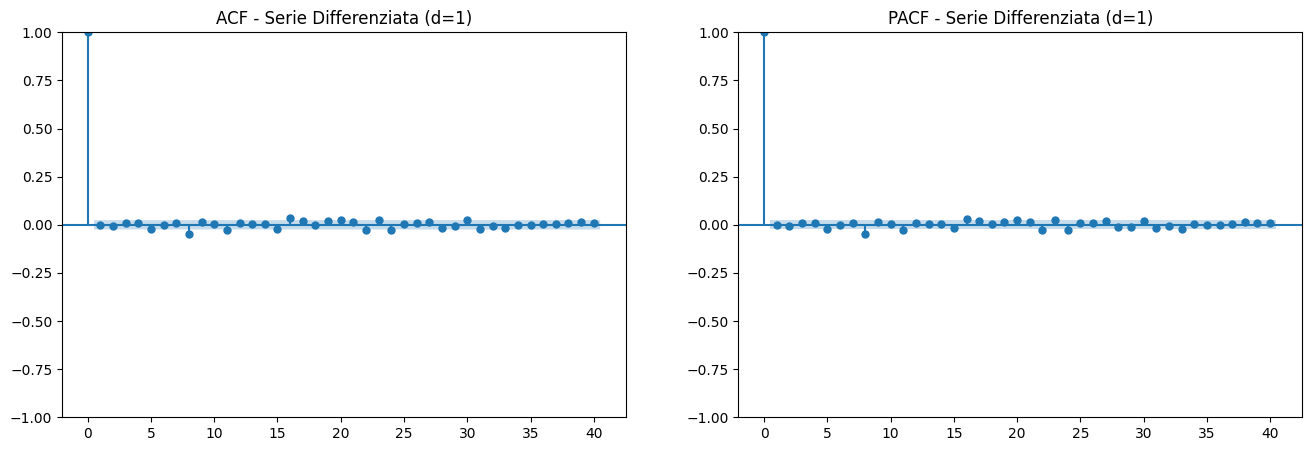

In [5]:
# Test di Dickey-Fuller
def check_stationarity(series, name):
    result = adfuller(series.dropna())
    print(f'ADF Test su {name} - p-value: {result[1]:.4f}')

check_stationarity(train_endog, "Train Log")
check_stationarity(train_endog.diff(), "Train Log Differenziato")

# ACF/PACF sulla serie differenziata (Identificazione p, q)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(train_endog.diff().dropna(), lags=40, ax=ax1, title='ACF - Serie Differenziata (d=1)')
plot_pacf(train_endog.diff().dropna(), lags=40, ax=ax2, title='PACF - Serie Differenziata (d=1)')
plt.show()

In [16]:
from statsmodels.tsa.stattools import adfuller

# Calcolo del test sulla serie differenziata (Log-Returns)
result = adfuller(ts_log.diff().dropna())

print("TABELLA ADF PER RELAZIONE (NVIDIA Log-Returns):")
print(f"{'-'*40}")
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4e}")
print(f"Critical Value (1%): {result[4]['1%']:.3f}")
print(f"Critical Value (5%): {result[4]['5%']:.3f}")
print(f"Critical Value (10%): {result[4]['10%']:.3f}")
print(f"{'-'*40}")

TABELLA ADF PER RELAZIONE (NVIDIA Log-Returns):
----------------------------------------
ADF Statistic: -15.8717
p-value: 8.9654e-29
Critical Value (1%): -3.431
Critical Value (5%): -2.862
Critical Value (10%): -2.567
----------------------------------------


In [9]:
combinazioni = [(0, 1, 0), (0, 1, 1), (1, 1, 0), (1, 1, 1), (2, 1, 2)]

# Ottimizzazione ARIMA
print("OTTIMIZZAZIONE ARIMA (AIC):")
for order in combinazioni:
    try:
        model = sm.tsa.ARIMA(train_endog, order=order).fit()
        print(f"ARIMA{order} | AIC: {model.aic:.4f}")
    except: continue

# Ottimizzazione SARIMAX (con Volume)
exog_log = np.log(df['Volume'])
train_exog = exog_log[:-steps_test]
test_exog = exog_log[-steps_test:]

print("\nOTTIMIZZAZIONE SARIMAX (AIC):")
for order in combinazioni:
    try:
        model = sm.tsa.statespace.SARIMAX(train_endog, exog=train_exog, order=order).fit(disp=False)
        print(f"SARIMAX{order} | AIC: {model.aic:.4f}")
    except: continue

OTTIMIZZAZIONE ARIMA (AIC):
ARIMA(0, 1, 0) | AIC: -24291.3160
ARIMA(0, 1, 1) | AIC: -24289.3117
ARIMA(1, 1, 0) | AIC: -24289.3167
ARIMA(1, 1, 1) | AIC: -24287.3159
ARIMA(2, 1, 2) | AIC: -24283.3918

OTTIMIZZAZIONE SARIMAX (AIC):
SARIMAX(0, 1, 0) | AIC: -24325.2796
SARIMAX(0, 1, 1) | AIC: -24323.2749
SARIMAX(1, 1, 0) | AIC: -24323.2807
SARIMAX(1, 1, 1) | AIC: -24321.2797
SARIMAX(2, 1, 2) | AIC: -24317.2797


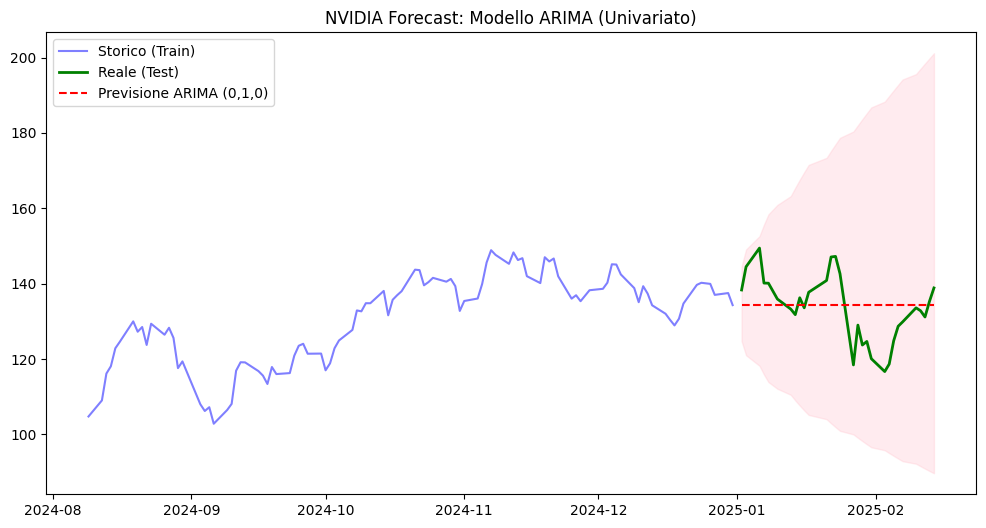

PERFORMANCE ARIMA -> MAE: 7.0740$ | RMSE: 8.7632$


In [13]:
# --- 1. FIT E FORECAST ARIMA ---
res_arima = sm.tsa.ARIMA(train_endog, order=(0, 1, 0)).fit()
f_arima = res_arima.get_forecast(steps=steps_test)
f_arima_log_mean = f_arima.predicted_mean
f_arima_ci = f_arima.conf_int()

# Sincronizzazione indici
f_arima_log_mean.index = test_endog.index
f_arima_ci.index = test_endog.index

# Trasformazione prezzi reali
f_arima_prices = np.exp(f_arima_log_mean)
lower_a = np.exp(f_arima_ci.iloc[:, 0])
upper_a = np.exp(f_arima_ci.iloc[:, 1])
real_prices = np.exp(test_endog)

# Calcolo Metriche ARIMA
mae_arima = mean_absolute_error(real_prices, f_arima_prices)
rmse_arima = np.sqrt(mean_squared_error(real_prices, f_arima_prices))

# GRAFICO ARIMA
plt.figure(figsize=(12, 6))
plt.plot(np.exp(train_endog[-100:]), label='Storico (Train)', color='blue', alpha=0.5)
plt.plot(real_prices, label='Reale (Test)', color='green', linewidth=2)
plt.plot(f_arima_prices, label='Previsione ARIMA (0,1,0)', color='red', linestyle='--')
plt.fill_between(f_arima_prices.index, lower_a, upper_a, color='pink', alpha=0.3)
plt.title('NVIDIA Forecast: Modello ARIMA (Univariato)')
plt.legend()
plt.show()

print(f"PERFORMANCE ARIMA -> MAE: {mae_arima:.4f}$ | RMSE: {rmse_arima:.4f}$")

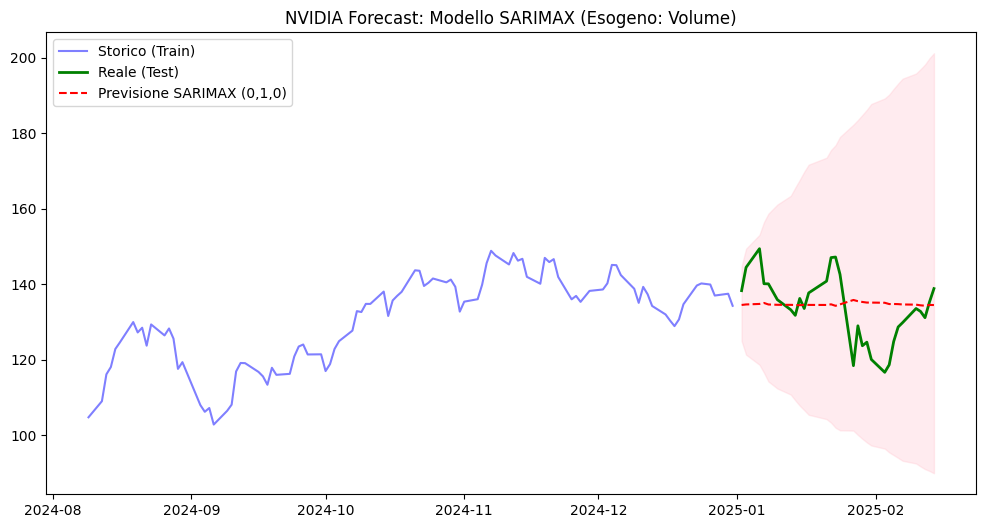

PERFORMANCE SARIMAX -> MAE: 7.2401$ | RMSE: 9.0177$


In [14]:
# --- 2. FIT E FORECAST SARIMAX ---
res_sarimax = sm.tsa.statespace.SARIMAX(train_endog, exog=train_exog, order=(0, 1, 0)).fit(disp=False)
f_sarimax = res_sarimax.get_forecast(steps=steps_test, exog=test_exog)
f_sarimax_log_mean = f_sarimax.predicted_mean
f_sarimax_ci = f_sarimax.conf_int()

# Sincronizzazione indici
f_sarimax_log_mean.index = test_endog.index
f_sarimax_ci.index = test_endog.index

# Trasformazione prezzi reali
f_sarimax_prices = np.exp(f_sarimax_log_mean)
lower_s = np.exp(f_sarimax_ci.iloc[:, 0])
upper_s = np.exp(f_sarimax_ci.iloc[:, 1])

# Calcolo Metriche SARIMAX
mae_sarimax = mean_absolute_error(real_prices, f_sarimax_prices)
rmse_sarimax = np.sqrt(mean_squared_error(real_prices, f_sarimax_prices))

# GRAFICO SARIMAX
plt.figure(figsize=(12, 6))
plt.plot(np.exp(train_endog[-100:]), label='Storico (Train)', color='blue', alpha=0.5)
plt.plot(real_prices, label='Reale (Test)', color='green', linewidth=2)
plt.plot(f_sarimax_prices, label='Previsione SARIMAX (0,1,0)', color='red', linestyle='--')
plt.fill_between(f_sarimax_prices.index, lower_s, upper_s, color='pink', alpha=0.3)
plt.title('NVIDIA Forecast: Modello SARIMAX (Esogeno: Volume)')
plt.legend()
plt.show()

print(f"PERFORMANCE SARIMAX -> MAE: {mae_sarimax:.4f}$ | RMSE: {rmse_sarimax:.4f}$")

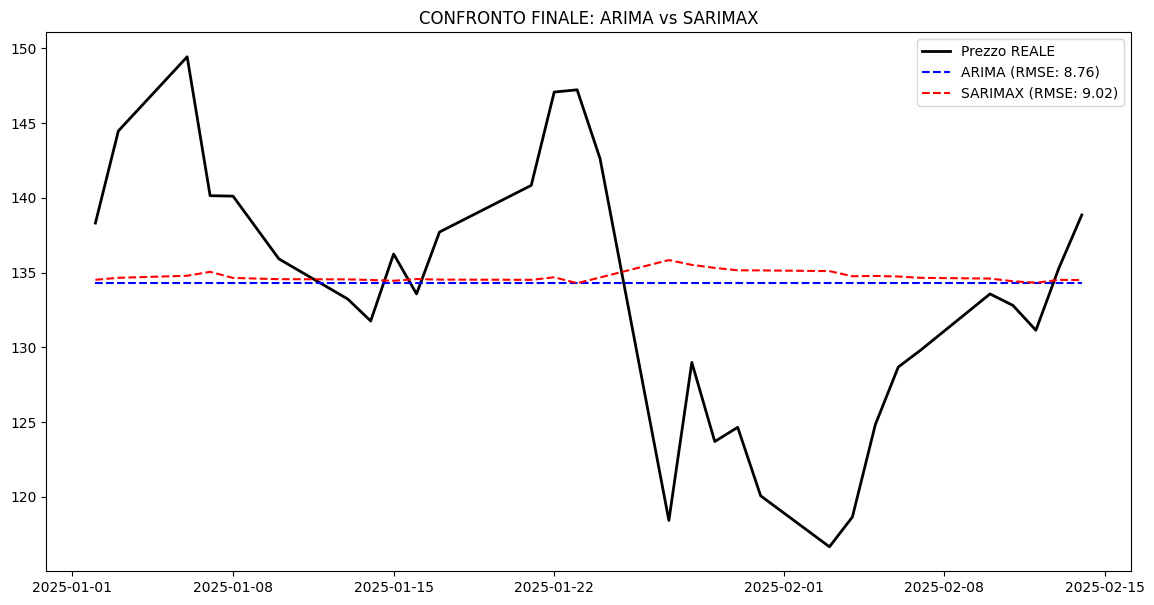

RIEPILOGO PERFORMANCE FINALE:
--------------------------------------------------
ARIMA   -> MAE: 7.0740 | RMSE: 8.7632
SARIMAX -> MAE: 7.2401 | RMSE: 9.0177
--------------------------------------------------
Diagnostica ARIMA (Ljung-Box p-value): 0.5202
Errore Percentuale Medio (MAPE): 5.40%

PREVISIONE PROSSIMI 7 GIORNI (Prezzi in $):
6558    138.850006
6559    138.850006
6560    138.850006
6561    138.850006
6562    138.850006
6563    138.850006
6564    138.850006
Name: predicted_mean, dtype: float64


In [15]:
# GRAFICO DI CONFRONTO
plt.figure(figsize=(14, 7))
plt.plot(real_prices, label='Prezzo REALE', color='black', linewidth=2)
plt.plot(f_arima_prices, label=f'ARIMA (RMSE: {rmse_arima:.2f})', color='blue', linestyle='--')
plt.plot(f_sarimax_prices, label=f'SARIMAX (RMSE: {rmse_sarimax:.2f})', color='red', linestyle='--')
plt.title('CONFRONTO FINALE: ARIMA vs SARIMAX')
plt.legend()
plt.show()

# ANALISI RESIDUI E MAPE (ARIMA VINCITORE)
residui = res_arima.resid
lb_p = sm.stats.acorr_ljungbox(residui, lags=[10], return_df=True)['lb_pvalue'].values[0]
mape = np.mean(np.abs((real_prices - f_arima_prices) / real_prices)) * 100

print(f"RIEPILOGO PERFORMANCE FINALE:")
print(f"--------------------------------------------------")
print(f"ARIMA   -> MAE: {mae_arima:.4f} | RMSE: {rmse_arima:.4f}")
print(f"SARIMAX -> MAE: {mae_sarimax:.4f} | RMSE: {rmse_sarimax:.4f}")
print(f"--------------------------------------------------")
print(f"Diagnostica ARIMA (Ljung-Box p-value): {lb_p:.4f}")
print(f"Errore Percentuale Medio (MAPE): {mape:.2f}%")

# PREVISIONE 7 GIORNI FUTURI
res_fut = sm.tsa.ARIMA(ts_log, order=(0, 1, 0)).fit()
fut_prices = np.exp(res_fut.get_forecast(steps=7).predicted_mean)
print("\nPREVISIONE PROSSIMI 7 GIORNI (Prezzi in $):")
print(fut_prices)

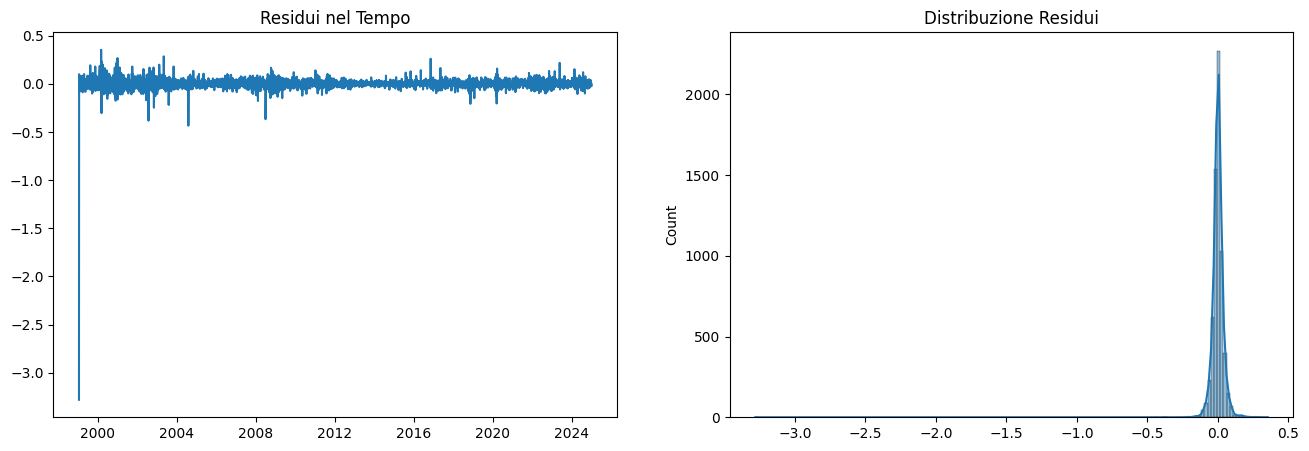

Ljung-Box p-value: 0.5202 | MAPE: 5.40%

PREVISIONE PREZZI PROSSIMI 7 GIORNI:
6558    138.850006
6559    138.850006
6560    138.850006
6561    138.850006
6562    138.850006
6563    138.850006
6564    138.850006
Name: predicted_mean, dtype: float64


In [8]:
# Analisi Residui ARIMA
residui = res_arima.resid
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].plot(residui)
ax[0].set_title('Residui nel Tempo')
sns.histplot(residui, kde=True, ax=ax[1])
ax[1].set_title('Distribuzione Residui')
plt.show()

# Validazione e Previsione Futura
lb_p = sm.stats.acorr_ljungbox(residui, lags=[10], return_df=True)['lb_pvalue'].values[0]
mape = np.mean(np.abs((real_prices - f_arima_prices) / real_prices)) * 100
print(f"Ljung-Box p-value: {lb_p:.4f} | MAPE: {mape:.2f}%")

# Previsione 7 giorni Futuri reali
model_fut = sm.tsa.ARIMA(ts_log, order=(0, 1, 0)).fit()
fut_prices = np.exp(model_fut.get_forecast(steps=7).predicted_mean)
print("\nPREVISIONE PREZZI PROSSIMI 7 GIORNI:")
print(fut_prices)